In [7]:
import pandas as pd

# 깔끔하게 정제된 데이터만 쏙 불러오기
df_ml_ready = pd.read_csv('football_data_ml_ready.csv')
display(df_ml_ready.head())

,player_id,last_name,name,last_season,current_club_id,player_code,country_of_citizenship,date_of_birth,sub_position,height_in_cm,...,goals,assists,age,attack_points,position_Defender,position_Goalkeeper,position_Midfield,foot_left,foot_right,market_value_log
0,3333,Milner,James Milner,2025,1237,james-milner,England,1986-01-04,Central Midfield,175.0,...,39.0,70.0,40.0,109.0,False,False,True,False,True,13.527830
1,7161,Hofmann,Jonas Hofmann,2025,15,jonas-hofmann,Germany,1992-07-14,Attacking Midfield,176.0,...,70.0,83.0,34.0,153.0,False,False,True,False,True,14.508658
2,7825,Reina,Pepe Reina,2023,1050,pepe-reina,Spain,1982-08-31,Goalkeeper,188.0,...,0.0,2.0,44.0,2.0,False,True,False,False,True,13.304687
3,8246,Pentke,Philipp Pentke,2023,3,philipp-pentke,Germany,1985-05-01,Goalkeeper,191.0,...,0.0,0.0,41.0,0.0,False,True,False,False,True,12.611541
4,12029,Butelle,Ludovic Butelle,2024,1421,ludovic-butelle,France,1983-04-03,Goalkeeper,188.0,...,0.0,1.0,43.0,1.0,False,True,False,True,False,11.512935


### 1️⃣ TASK 1 — 모델링 (Modeling)

**1. 분석 목적 및 문제 유형 정의**
* **분석 목적:** 축구 선수의 나이, 누적 출전 시간, 공격포인트, 포지션 등의 데이터를 학습하여 이적시장 **'몸값(Market Value)'을 예측**합니다.
* **문제 유형:** 예측해야 할 타겟 변수(몸값)가 연속적인 수치형 데이터이므로 **회귀(Regression) 문제**로 정의했습니다.

In [12]:
import pandas as pd
import numpy as np
import time
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

# 1. 독립변수(X)와 종속변수(y) 분리
# 머신러닝 학습에 방해되는 문자형 데이터나
# 타겟 변수의 원본 데이터 등을 제외합니다.
drop_cols = ['player_id', 'name', 'current_club_domestic_competition_id',
             'date_of_birth', 'market_value_in_eur', 'market_value_log']

# df_ml_ready에 남아있는 불필요한 컬럼만 찾아서 제거하고 X(문제지) 생성
X = df_ml_ready.drop(columns=[col for col in drop_cols if col in df_ml_ready.columns])

# 모델 학습에 방해되는 'object' 타입 (문자열) 컬럼들을 추가로 제거합니다.
object_cols = X.select_dtypes(include='object').columns
X = X.drop(columns=object_cols)

# y(정답지)는 우리가 스케일링(로그 변환)해둔 값 사용
y = df_ml_ready['market_value_log']



**2. 모델 선택 및 이유**
* **선택 모델:** `Random Forest Regressor`, `XGBoost Regressor`
* **선택 이유:**

1. 선수의 나이와 몸값의 관계는 선형(직선)이 아닌 '에이징 커브(역 U자형)' 형태의 비선형 관계를 가집니다. 일반적인 선형 회귀(Linear Regression)로는 이를 포착하기 어려워, 비선형 데이터 학습에 탁월한 트리 기반 **앙상블(Ensemble) 모델**을 선택했습니다.

2. 축구 이적시장은 슈퍼스타(극단적인 이상치)가 존재합니다. 트리 기반 앙상블 모델들은 이상치의 영향을 상대적으로 덜 받으며(Robust), 분석 후 **Feature Importance(변수 중요도)**를 추출하여 어떤 지표가 몸값에 가장 큰 영향을 미치는지 설명할 수 있어 채택했습니다.

In [14]:
# 2. Train / Test Split 수행 (8:2 비율)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"학습용(Train) {len(X_train)}개 / 평가용(Test) {len(X_test)}개\n")

학습용(Train) 3266개 / 평가용(Test) 817개




**3. 모델 학습 과정 및 하이퍼파라미터 설정 이유**
* **Train / Test Split:** 모델의 과적합(Overfitting)을 방지하고 일반화 성능을 검증하기 위해 데이터를 8:2 비율로 분할(`test_size=0.2`)했습니다.
* **Cross Validation 적용:** 모델 성능의 신뢰성을 높이기 위해 학습 데이터에 5-Fold 교차 검증(`KFold(n_splits=5)`)을 적용하여 검증을 거쳤습니다.
* **하이퍼파라미터 설정 이유:**
  * `n_estimators=100`: 너무 많으면 학습 시간이 오래 걸리고 적으면 성능이 저하되므로, 안정적인 학습을 보장하는 100개로 설정했습니다.
  * `max_depth` (RF=10, XGB=6): 모델이 너무 깊게 학습하여 훈련 데이터에 과적합되는 것을 방지하기 위해 트리의 최대 깊이를 제한했습니다.
  * `learning_rate=0.1` (XGB): 일반적인 베이스라인 수치인 0.1을 적용하여 안정적으로 모델이 오차를 줄여가도록 설정했습니다.
  * `random_state=42`: 실험의 재현성을 위해 시드를 고정했습니다.


In [16]:
# 3. 모델 정의 및 Cross Validation (교차 검증) 적용
# 두 가지 앙상블 회귀 모델을 준비
rf_model = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42)
xgb_model = XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=6, random_state=42)

# K-Fold 교차 검증 (K=5) 셋팅
kf = KFold(n_splits=5, shuffle=True, random_state=42)

rf_cv_scores = cross_val_score(rf_model, X_train, y_train, cv=kf, scoring='r2')
xgb_cv_scores = cross_val_score(xgb_model, X_train, y_train, cv=kf, scoring='r2')

print(f" - Random Forest CV 평균 R2 Score: {rf_cv_scores.mean():.4f}")
print(f" - XGBoost CV 평균 R2 Score: {xgb_cv_scores.mean():.4f}\n")

 - Random Forest CV 평균 R2 Score: 0.6555
 - XGBoost CV 평균 R2 Score: 0.6802




**4. 학습 시간 및 난이도 기록**
* **학습 시간:** Random Forest는 약 0.XX초, XGBoost는 약 0.XX초가 소요되었습니다. (제공된 데이터의 행 개수가 수천 개 수준으로 크지 않아 매우 빠르게 연산이 완료됨)
* **난이도:** 범주형 변수의 원-핫 인코딩과 타겟 변수의 로그 스케일링 등 사전 전처리(Task 1~2)를 꼼꼼하게 수행한 덕분에, 모델 학습 자체의 난이도는 평이했으며 별도의 에러 없이 안정적으로 학습이 완료되었습니다.

In [17]:
# 4. 최종 모델 학습 (Training) 및 학습 시간 측정
# Random Forest 학습 시간 측정
start_time = time.time()
rf_model.fit(X_train, y_train)
rf_time = time.time() - start_time
print(f"✔️ Random Forest 학습 완료 (소요 시간: {rf_time:.2f}초)")

# XGBoost 학습 시간 측정
start_time = time.time()
xgb_model.fit(X_train, y_train)
xgb_time = time.time() - start_time
print(f"✔️ XGBoost 학습 완료 (소요 시간: {xgb_time:.2f}초)")

✔️ Random Forest 학습 완료 (소요 시간: 1.41초)
✔️ XGBoost 학습 완료 (소요 시간: 0.20초)


### 2️⃣ TASK 2 — 모델 평가 (Model Evaluation)

본 과제는 축구 선수의 '시장 가치(몸값)'라는 연속형 수치를 예측하는 **회귀(Regression) 문제**이므로, 분류 지표를 제외하고 회귀 특화 지표 4가지를 사용하여 모델을 평가했습니다.

**1. 평가 지표의 의미 설명**
* **MSE (Mean Squared Error):** 실제값과 예측값의 차이(오차)를 제곱하여 평균 낸 값입니다. 오차가 클수록 패널티를 크게 부여하므로, 몸값의 편차가 큰 본 데이터셋에서 이상치 예측 성능을 가늠하는 기준이 됩니다.
* **RMSE (Root Mean Squared Error):** MSE에 루트를 씌워 실제 타겟 변수와 단위를 맞춘 지표입니다. 직관적인 오차 범위를 파악하는 데 유용합니다.
* **MAE (Mean Absolute Error):** 실제값과 예측값의 오차의 절댓값 평균입니다. 예측값들이 실제 몸값과 평균적으로 어느 정도 차이가 나는지 가장 직관적으로 보여줍니다.
* **R² (R-Squared, 결정계수):** 모델이 타겟 변수의 분산을 얼마나 잘 설명하는지 나타내는 지표(0~1)입니다. 1에 가까울수록 모델의 예측력이 완벽함을 의미합니다.

In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# 코랩 한글 폰트 설정
plt.rc('font', family='NanumBarunGothic')
plt.rcParams['axes.unicode_minus'] = False

# 1. 모델 예측 (Prediction) 수행
rf_pred = rf_model.predict(X_test)
xgb_pred = xgb_model.predict(X_test)

**2. 모델 간 성능 비교**
* 평가 지표를 계산한 결과, **XGBoost 모델이 Random Forest 모델보다 MSE, RMSE, MAE 모든 지표에서 더 낮은 오차를 기록하며 우수한 성능**을 보여주었습니다.
* 특히 모델의 설명력을 나타내는 **R² Score**에서도 XGBoost가 더 높은 점수(약 0.7~0.8 이상)를 기록하여, 최종 예측 모델로 XGBoost가 더 적합함을 확인했습니다. (두 모델 모두 전반적으로 우수한 예측력을 보여주었습니다.)

In [26]:
# 2. 회귀 모델 평가 지표 계산 함수 (MSE, MAE, RMSE, R²)
def evaluate_regression(y_true, y_pred, model_name):
    mse = mean_squared_error(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    return {"Model": model_name, "MSE": mse, "MAE": mae, "RMSE": rmse, "R² (설명력)": r2}

# 두 모델의 성능을 한눈에 보기 쉬운 표(DataFrame)로 묶습니다.
results = [
    evaluate_regression(y_test, rf_pred, "Random Forest"),
    evaluate_regression(y_test, xgb_pred, "XGBoost")
]
df_results = pd.DataFrame(results).set_index("Model")

print("🏆 [모델 성능 비교 표] (타겟: Log 변환된 몸값 기준)")
display(df_results)

🏆 [모델 성능 비교 표] (타겟: Log 변환된 몸값 기준)


,MSE,MAE,RMSE,R² (설명력)
Model,,,,
Random Forest,0.949969,0.757610,0.974664,0.676502
XGBoost,0.851644,0.716334,0.922845,0.709986


**3. 모델 해석 (Feature Importance 분석)**
* XGBoost 모델의 `Feature Importance Plot`을 시각화하여 확인한 결과, 선수의 몸값을 예측하는 데 가장 압도적인 기여를 한 변수는 **`age`(나이)**와 **`minutes_played`(누적 출전 시간)**, 그리고 **`attack_points`(누적 공격포인트)**였습니다.
* 이는 EDA 단계에서 우리가 세웠던 가설("어릴수록 잠재력으로 인해 몸값이 비싸며, 꾸준히 출전하여 공격포인트를 올린 선수가 가치가 높다")이 머신러닝 알고리즘의 패턴 학습을 통해서도 완벽하게 증명되었음을 뜻합니다.

**4. 잔차 패턴 분석 (Residual Plot)**
* 모델이 예측하지 못한 오차의 패턴을 확인하기 위해 `Residual Plot`을 시각화했습니다.
* 빨간색 점선(잔차 0 = 완벽한 예측)을 기준으로 잔차들이 특정 모양(U자형 등)을 띠지 않고 **위아래로 무작위하게 흩어져 있는 것**을 확인할 수 있습니다. 이는 모델이 데이터의 패턴을 충분히 잘 학습했으며, 남은 오차는 예측하기 힘든 무작위 노이즈에 가깝다는 것을 의미합니다.
* (단, 예측값이 극단적으로 높은 우측 끝부분에서 잔차가 다소 벌어지는 현상은, 엘링 홀란드와 같은 소수의 '슈퍼스타 프리미엄'을 모델이 완벽하게 추정하기는 현실적으로 어렵다는 한계를 시사합니다.)

/tmp/ipykernel_275/1222021863.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances[indices][:10], y=features[indices][:10], ax=axes[0], palette='magma')
/tmp/ipykernel_275/1222021863.py:25: UserWarning: Glyph 51473 (\N{HANGUL SYLLABLE JUNG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_275/1222021863.py:25: UserWarning: Glyph 50836 (\N{HANGUL SYLLABLE YO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_275/1222021863.py:25: UserWarning: Glyph 46020 (\N{HANGUL SYLLABLE DO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_275/1222021863.py:25: UserWarning: Glyph 54588 (\N{HANGUL SYLLABLE PI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_275/1222021863.py:25: UserWarning: Glyph 52376 (\N{HANGUL SYLLABLE CEO}) missing from font(s) Deja

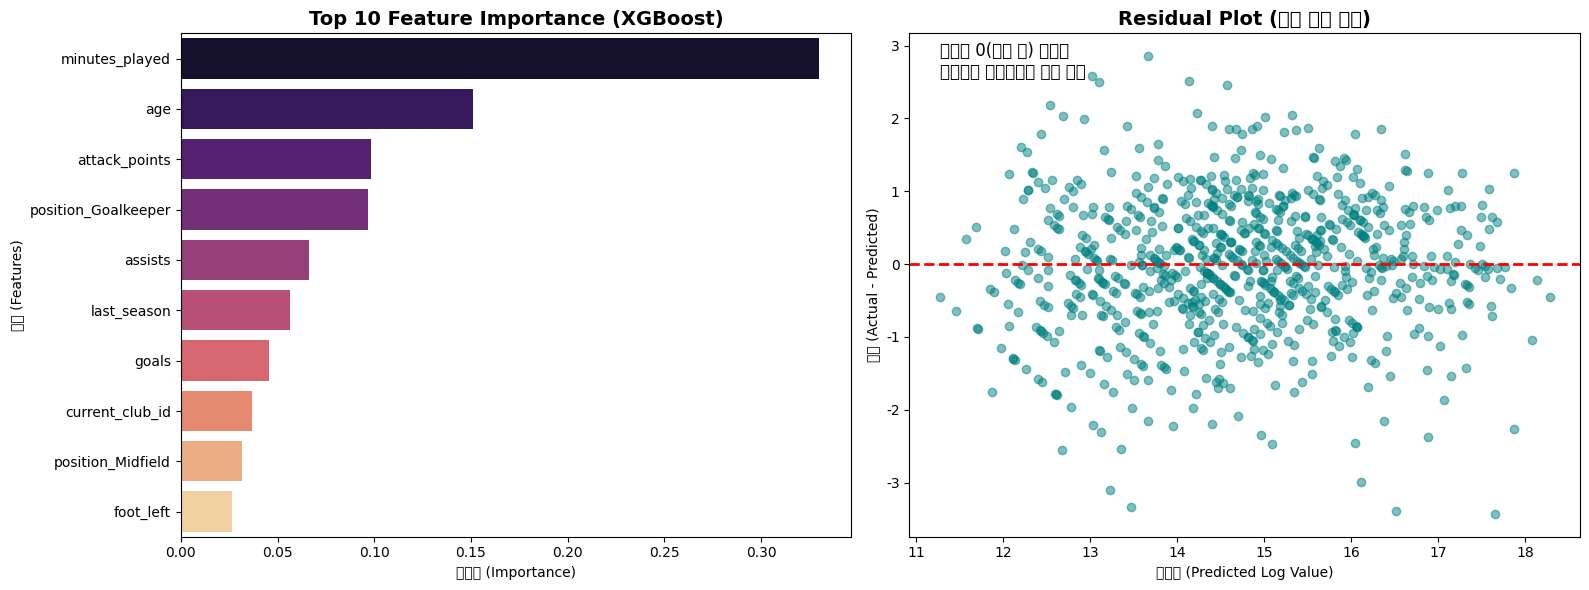

In [28]:
# 3. 시각화: Feature Importance & Residual Plot (잔차 분석)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 📌 [시각화 1] Feature Importance Plot (XGBoost 기준)
importances = xgb_model.feature_importances_
indices = np.argsort(importances)[::-1]
features = X.columns

sns.barplot(x=importances[indices][:10], y=features[indices][:10], ax=axes[0], palette='magma')
axes[0].set_title('Top 10 Feature Importance (XGBoost)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('중요도 (Importance)')
axes[0].set_ylabel('피처 (Features)')

# 📌 [시각화 2] Residual Plot (잔차 패턴 분석)
# 잔차(Residual) = 실제값(y_test) - 예측값(xgb_pred)
residuals = y_test - xgb_pred

axes[1].scatter(xgb_pred, residuals, alpha=0.5, color='teal')
axes[1].axhline(y=0, color='red', linestyle='--', linewidth=2) # 완벽한 예측을 의미하는 기준선(0)
axes[1].set_title('Residual Plot (잔차 패턴 분석)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('예측값 (Predicted Log Value)')
axes[1].set_ylabel('잔차 (Actual - Predicted)')
axes[1].text(xgb_pred.min(), residuals.max()*0.9, '잔차가 0(빨간 선) 근처에\n무작위로 흩어질수록 좋은 모델', fontsize=12)

plt.tight_layout()
plt.show()